In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import struct
import hashlib
import os
from sklearn.model_selection import train_test_split
import config as cfg

In [32]:
os.makedirs(cfg.EXPLORATION_FOLDER, exist_ok=True)

# 1. Load ECG Training Data

In [33]:
def read_zip_binary(zip_path):
    ragged_array = []
    with zipfile.ZipFile(zip_path, 'r') as zf:
        # Extract base filename (e.g., X_train.bin inside X_train.zip)
        inner_path = zip_path.split("/")[-1].split(".")[0] + ".bin"
        with zf.open(inner_path, 'r') as r:
            while True:
                size_bytes = r.read(4)
                if not size_bytes:
                    break
                sub_array_size = struct.unpack('i', size_bytes)[0]
                sub_array = list(struct.unpack(f'{sub_array_size}h', r.read(sub_array_size * 2)))
                ragged_array.append(sub_array)
    return ragged_array


def load(cfg, train_data: bool):
    """
    Load ECG data from a zip file.
    """

    if train_data:
        # Load signals
        print("Reading Train ECG signals from:", cfg.X_TRAIN)
        ecg_signals = read_zip_binary(cfg.X_TRAIN)
        print(f"Loaded {len(ecg_signals)} Train ECG signals.")

        # Load labels
        print("Reading Training labels from:", cfg.Y_TRAIN)
        labels_df = pd.read_csv(cfg.Y_TRAIN, header=None, names=["label"])
        print(f"Loaded {len(labels_df)} labels.")
        return ecg_signals, labels_df
    else:
        print("Reading Test ECG signals from:", cfg.X_TEST)
        test_ecg_signals = read_zip_binary(cfg.X_TEST)
        print(f"Loaded {len(test_ecg_signals)} Test ECG signals.")
        return test_ecg_signals, None
#cg_signals = read_zip_binary(zip_data_path)


In [34]:
ecg_signals, labels_df = load(cfg, train_data=True)
test_ecg_signals, _ = load(cfg, train_data=False)

Reading Train ECG signals from: data/X_train.zip
Loaded 6179 Train ECG signals.
Reading Training labels from: data/y_train.csv
Loaded 6179 labels.
Reading Test ECG signals from: data/X_test.zip
Loaded 2649 Test ECG signals.


In [35]:
class_names = {
    0: "Normal",
    1: "AF (Atrial Fibrillation)",
    2: "Other Rhythm",
    3: "Noisy"
}

In [36]:
labels_df

,label
0,2
1,2
2,2
3,0
4,0
...,...
6174,0
6175,0
6176,0
6177,2


# Missing Values and Data Issues

Before starting model development, we explored the dataset for potential issues:

- **Missing Labels**:  
  We checked the `label` column for any missing values.  
  → **Result**: 0 missing labels

- **Empty ECG Signals**:  
  We identified signals with zero length.  
  → **Result**: 0 empty signals

- **Duplicate ECG Signals**:  
  We hashed the content of each signal to find exact duplicates.  
  → **Result**: 155 duplicate groups found  
  → Example group: 2 identical signals at indices [5, 5248]

These checks helped us understand the structure and quality of the data. No critical issues were found, though a few duplicate signals were observed.


In [37]:
print(f"Number of Missing Labels: {labels_df["label"].isna().sum()}")

Number of Missing Labels: 0


In [38]:
empty_indices = []
for i, signal in enumerate(ecg_signals):
    if len(signal) == 0:
        empty_indices.appen(i)
print(f"Empty signals found at indices: {empty_indices}")

Empty signals found at indices: []


In [39]:
# Create a hash for each ECG signal
signal_hashes = []
for signal in ecg_signals:
    signal_array = np.array(signal, dtype=np.int16)
    signal_bytes = signal_array.tobytes()
    signal_hash = hashlib.md5(signal_bytes).hexdigest()
    signal_hashes.append(signal_hash)

# Group signal indices by their hash
hash_to_indices = {}  # regular dictionary
for idx, hash_val in enumerate(signal_hashes):
    if hash_val in hash_to_indices:
        hash_to_indices[hash_val].append(idx)
    else:
        hash_to_indices[hash_val] = [idx]

# Get only groups that have duplicates
duplicate_groups = [group for group in hash_to_indices.values() if len(group) > 1]

# Print duplicate group sizes and indices
if duplicate_groups:
    print("Found duplicate groups:")
    for i, group in enumerate(duplicate_groups):
        print(f"  Group {i+1}: {len(group)} identical signals at indices {group}")
else:
    print("No duplicate signals found.")


Found duplicate groups:
  Group 1: 2 identical signals at indices [5, 5248]
  Group 2: 2 identical signals at indices [58, 275]
  Group 3: 2 identical signals at indices [62, 5133]
  Group 4: 2 identical signals at indices [74, 4891]
  Group 5: 2 identical signals at indices [78, 4917]
  Group 6: 2 identical signals at indices [105, 2190]
  Group 7: 2 identical signals at indices [111, 2574]
  Group 8: 2 identical signals at indices [129, 1651]
  Group 9: 2 identical signals at indices [132, 5105]
  Group 10: 2 identical signals at indices [143, 2585]
  Group 11: 2 identical signals at indices [161, 830]
  Group 12: 2 identical signals at indices [195, 4128]
  Group 13: 2 identical signals at indices [203, 4505]
  Group 14: 2 identical signals at indices [256, 5145]
  Group 15: 2 identical signals at indices [270, 5364]
  Group 16: 2 identical signals at indices [277, 5093]
  Group 17: 2 identical signals at indices [362, 2980]
  Group 18: 2 identical signals at indices [367, 369]
  Gr

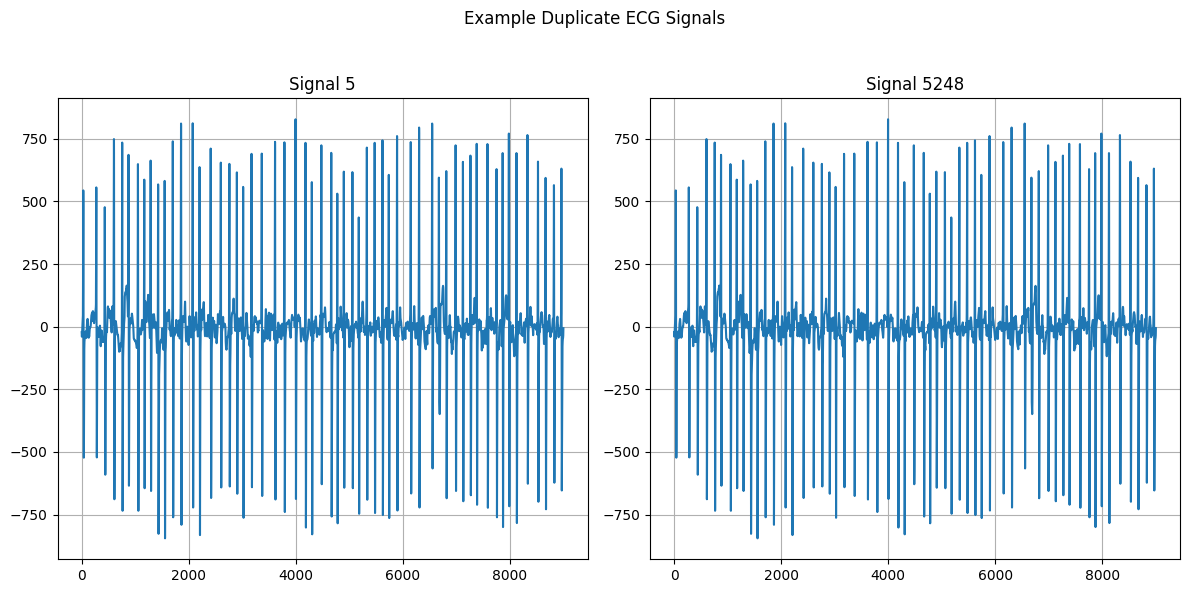

In [40]:
# Plot up to 4 signals from the first duplicate group
if duplicate_groups:
    example_group = duplicate_groups[0]
    n = min(4, len(example_group))

    plt.figure(figsize=(12, 6))
    for i in range(n):
        idx = example_group[i]
        plt.subplot(1, n, i + 1)
        plt.plot(ecg_signals[idx])
        plt.title(f"Signal {idx}")
        plt.grid(True)

    plt.suptitle("Example Duplicate ECG Signals")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(cfg.EXPLORATION_FOLDER, "duplicates.png"))
    plt.show()
    plt.close()

 # 3. Class Distribution

 In the provided training set, we analyzed how many ECG signals belong to each class:

| Class | Name                      | Count |
|-------|---------------------------|-------|
| 0     | Normal                    | 3638  |
| 1     | AF (Atrial Fibrillation) | 549   |
| 2     | Other Rhythm             | 1765  |
| 3     | Noisy                    | 227   |

This shows that the dataset is imbalanced, with the **Normal** class being the most common and the **Noisy** and **AF** classes being underrepresented.

In [41]:
label_counts = labels_df["label"].value_counts().sort_index()
label_counts

label
0    3638
1     549
2    1765
3     227
Name: count, dtype: int64

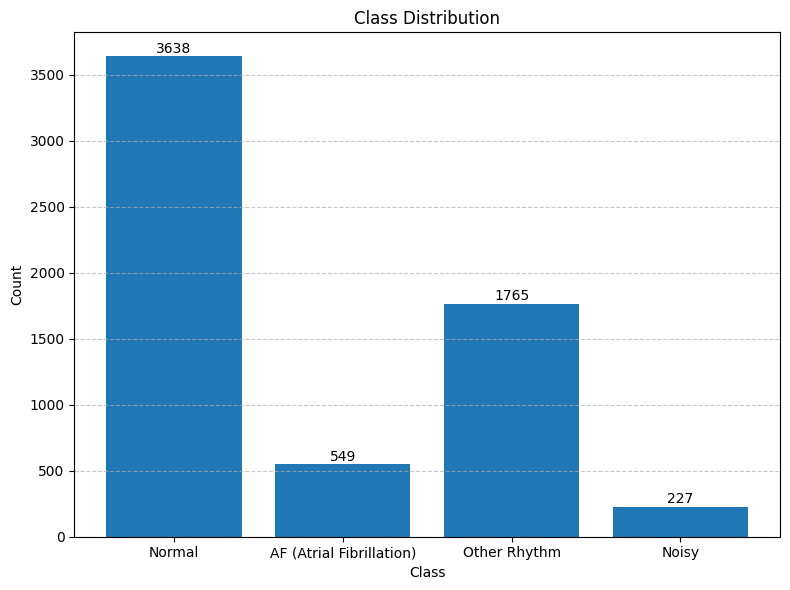

In [47]:
plt.figure(figsize=(8, 6))
bars = plt.bar(class_names.values(), label_counts.values)


for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count),
             ha='center', va='bottom', fontsize=10)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(cfg.EXPLORATION_FOLDER, "class_distribution.png"))
plt.show()
plt.close()

# 4. Signal Length Distribution

We analyzed the length of ECG signals in the training set. The histogram below shows the distribution of signal lengths on a **logarithmic scale**, which helps to reveal both common and rare lengths.

### Observations:
- Most signals fall between **3,000 and 18,000 samples** in length.
- There is a sharp peak near **9,000 samples**, indicating that many signals have a standardized length.
- The log scale reveals a long tail of less frequent signal lengths.

Understanding this distribution helps us choose appropriate window sizes or normalization steps for modeling.


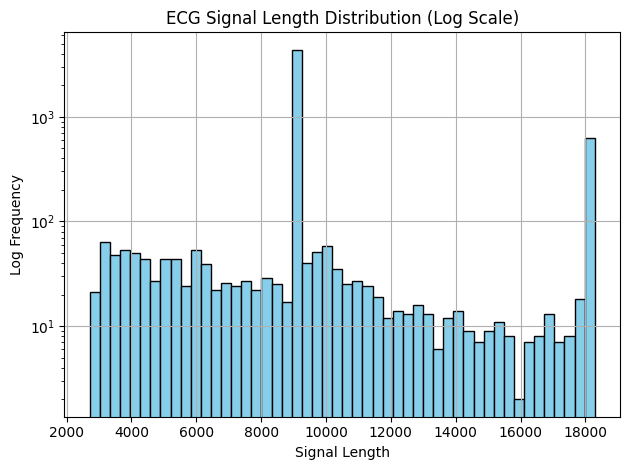

In [43]:
signal_lengths = [len(signal) for signal in ecg_signals]
plt.hist(signal_lengths, bins=50, color="skyblue", edgecolor="black")
plt.yscale("log")
plt.title("ECG Signal Length Distribution (Log Scale)")
plt.xlabel("Signal Length")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(cfg.EXPLORATION_FOLDER, "length_distribution.png"))
plt.show()
plt.close()

# 5. Summary Statistics by Class

We computed basic statistics (mean, standard deviation, minimum, and maximum values) for the raw ECG signals in the provided training set, grouped by class:

| Class | Name                      | Mean     | Std Dev  | Min     | Max     |
|-------|---------------------------|----------|----------|---------|---------|
| 0     | Normal                    | 7.78     | 228.92   | -10636  | 8318    |
| 1     | AF (Atrial Fibrillation) | 8.05     | 201.12   | -6323   | 6342    |
| 2     | Other Rhythm             | 6.63     | 234.00   | -7360   | 8257    |
| 3     | Noisy                    | 5.31     | 502.39   | -7030   | 7440    |

This shows that **Noisy signals** have a much higher standard deviation, reflecting their irregular nature. The **Normal** and **AF** signals are more centered and consistent in their amplitude ranges.


In [44]:
class_stats = []

for class_id in sorted(labels_df["label"].unique()):
    signals = [ecg_signals[i] for i in labels_df[labels_df["label"] == class_id].index]
    flattened = [value for signal in signals for value in signal]
    class_stats.append({
        "class": class_names[class_id],
        "mean": np.mean(flattened),
        "std": np.std(flattened),
        "min": np.min(flattened),
        "max": np.max(flattened)
    })

pd.DataFrame(class_stats)

,class,mean,std,min,max
0,Normal,7.776893,228.917823,-10636,8318
1,AF (Atrial Fibrillation),8.054836,201.118132,-6323,6342
2,Other Rhythm,6.634972,234.002699,-7360,8257
3,Noisy,5.312113,502.393673,-7030,7440


# 6. Plot Example Signal per Class


The figure below shows one example ECG signal from each of the four classes in the training set:


### Observations:
- **Class 0 (Normal)**: Clear, consistent waveform with regular rhythm and amplitude.
- **Class 1 (AF - Atrial Fibrillation)**: Irregular pattern with fluctuating amplitudes and less consistent spacing between peaks.
- **Class 2 (Other Rhythm)**: Rhythmic but with abnormal spike patterns that differ from both normal and AF.
- **Class 3 (Noisy)**: High noise level, making the waveform hard to interpret.

These examples help visualize the differences between classes and highlight why classification can be challenging, especially in the presence of noise or rhythm irregularities.


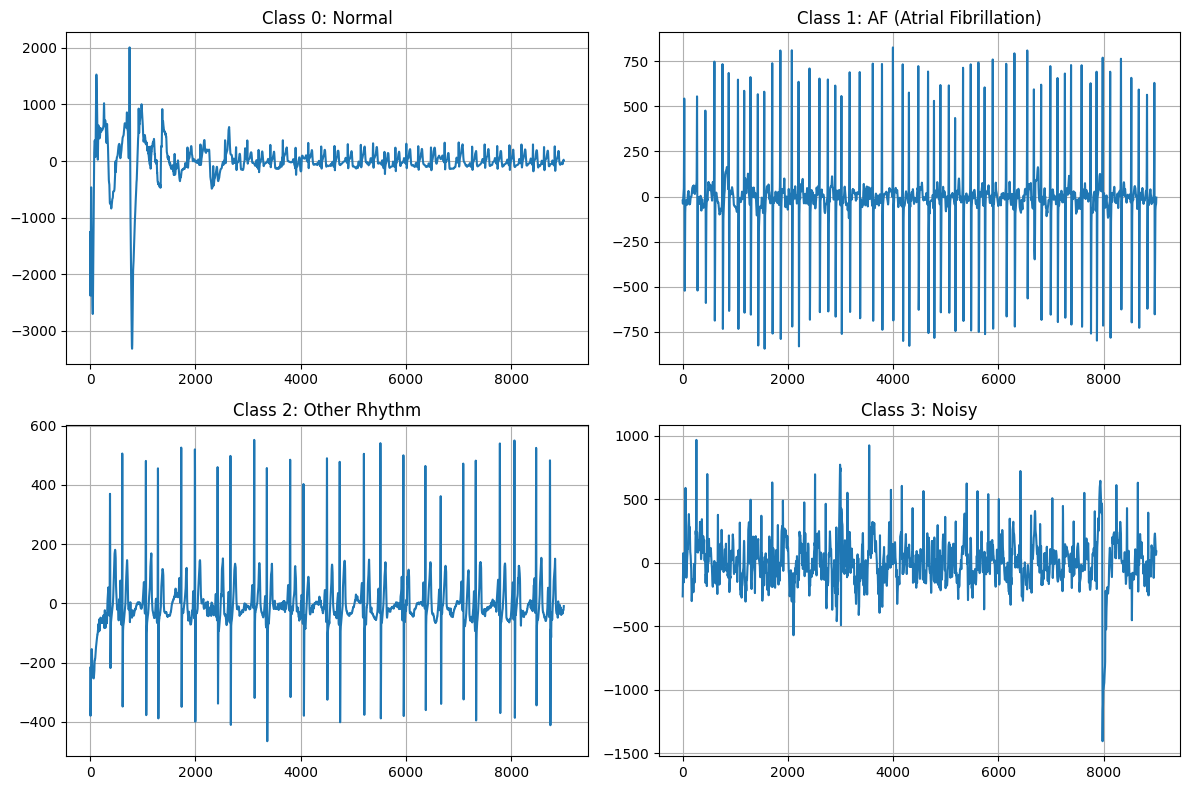

In [45]:
plt.figure(figsize=(12, 8))
for class_id in range(4):
    index = labels_df[labels_df["label"] == class_id].index[0]
    plt.subplot(2, 2, class_id+1)
    plt.plot(ecg_signals[index])
    plt.title(f"Class {class_id}: {class_names[class_id]}")
    plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(cfg.EXPLORATION_FOLDER, "signlas.png"))
plt.show()

# 7. Create Stratified Train/Validation Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    ecg_signals, labels_df["label"],
    test_size=0.2,
    stratify=labels_df["label"],
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")


Training samples: 4943
Validation samples: 1236
